## Setup

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
import torchvision.transforms.functional as TF
import torchvision

import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients, Occlusion, NoiseTunnel
from captum.attr import visualization as viz

from skimage.segmentation import slic, mark_boundaries
from captum.attr import ShapleyValueSampling

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Carregar Modelo

In [3]:
def get_pretrained_model_optimized():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)

In [4]:
classes = ["airplane", "bird", "car", "cat", "deer", "dog", "horse", "monkey", "ship", "truck"]

stats_stl10 = ((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
BATCH_SIZE = 64

transform_pt_train = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])
transform_pt_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(*stats_stl10),
])

testset_pt = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_pt_test)
loader_pt_test = torch.utils.data.DataLoader(testset_pt, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [5]:
model_loaded = get_pretrained_model_optimized()
model_loaded.load_state_dict(torch.load('./models/model_resnet_stl10.pth', map_location=device))
model_loaded.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Funções Auxiliares

In [6]:
def visualize_attribution(attribution_tensor, original_img_tensor, stats, title="Atribuição"):
    # 1. Preparar a imagem original para exibição (Desnormalizar)
    mean, std = stats
    mean = torch.tensor(mean).view(3, 1, 1).to(original_img_tensor.device)
    std = torch.tensor(std).view(3, 1, 1).to(original_img_tensor.device)
    
    img_denorm = original_img_tensor.clone() * std + mean
    img_denorm = img_denorm.clamp(0, 1)
    
    # Converter para numpy [H, W, C] para o matplotlib
    original_img_np = img_denorm.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    
    # 2. Preparar o tensor de atribuição (mover para CPU e formato HWC)
    attribution_np = attribution_tensor.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    
    # 3. Usar o visualizador do Captum
    fig, ax = viz.visualize_image_attr(
        attribution_np, 
        original_img_np, 
        method="blended_heat_map", 
        sign="all",
        show_colorbar=True,
        title=title
    )
    return fig

In [7]:
def explain_with_occlusion(model, img_tensor, target_label_idx, stats):
    model.eval()
    
    # 1. Inicializa o algoritmo
    occlusion = Occlusion(model)

    print("Calculando Oclusão... (Isso pode demorar um pouco)")
    # 2. Calcula a atribuição
    # sliding_window_shapes: Tamanho do bloco que vai "tampar" a imagem (C, H, W).
    # strides: O passo do deslizamento. Menor = mais resolução, mais lento.
    attributions_occ = occlusion.attribute(
        img_tensor,
        target=target_label_idx, # Explicar a classe real
        sliding_window_shapes=(3, 45, 45), 
        strides=(3, 15, 15),
        baselines=0 # O valor que preenche o bloco (0 = cinza médio na normalização)
    )
    print("Concluído.")
    
    # 3. Visualizar
    visualize_attribution(
        torch.abs(attributions_occ), 
        img_tensor, 
        stats, 
        title="Oclusão (Regiões de Impacto)"
    )

In [8]:
def explain_with_ig(model, img_tensor, target_label_idx, stats):
    model.eval()
    
    # 1. Inicializa o algoritmo
    ig = IntegratedGradients(model)

    print("Calculando Integrated Gradients...")
    # 2. Calcula a atribuição
    # n_steps: O número de passos na integral. 50 a 200 é usual.
    attributions_ig = ig.attribute(
        img_tensor, 
        target=target_label_idx,
        n_steps=50,
        internal_batch_size=16 # Ajuste se der erro de memória na GPU
    )
    print("Concluído.")

    # 3. Visualizar
    # O IG mostra bem pixels positivos (ajudaram a decisão) e negativos (atrapalharam)
    # O método "blended_heat_map" com sign="all" mostra Verde(positivo) e Vermelho(negativo)
    visualize_attribution(
        attributions_ig, 
        img_tensor, 
        stats, 
        title="Integrated Gradients (Nível de Pixel)"
    )

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_side_by_side(attr_tensor, original_img_tensor, stats, title="Atribuição"):
    """
    Plota lado a lado: Imagem Original vs. Heatmap dos Gradientes (sem fundo).
    """
    # --- 1. Processar Imagem Original ---
    mean, std = stats
    mean = torch.tensor(mean).view(3, 1, 1).to(original_img_tensor.device)
    std = torch.tensor(std).view(3, 1, 1).to(original_img_tensor.device)
    
    img_denorm = original_img_tensor.clone() * std + mean
    img_np = img_denorm.clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().detach().numpy()

    # --- 2. Processar o Heatmap (Saliency Map) ---
    # attr_tensor vem como [1, 3, H, W]
    attr_np = attr_tensor.squeeze(0).cpu().detach().numpy()
    
    # Achatar os canais: Calcula a magnitude média da importância entre R, G e B
    # Resultado: uma matriz 2D [H, W]
    heatmap = np.mean(np.abs(attr_np), axis=0)
    
    # Normalização Min-Max para o plot ficar brilhante (0 a 1)
    # Adicionamos 1e-8 para evitar divisão por zero se o gradiente for todo zero
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # --- 3. Plotagem ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Esquerda: Imagem Original
    axes[0].imshow(img_np)
    axes[0].set_title("Imagem Original")
    axes[0].axis('off')
    
    # Direita: Heatmap Puro
    # cmap='inferno' ou 'hot' são ótimos para fundo preto
    # cmap='gray' é bom para parecer um "Raio-X"
    im = axes[1].imshow(heatmap, cmap='inferno', vmin=0, vmax=1)
    axes[1].set_title(f"Saliency Map (IG)\n{title}")
    axes[1].axis('off')
    
    # Barra de cores lateral
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Importância Relativa')

    plt.tight_layout()
    plt.show()

In [10]:
def analyze_class_explanation(model, loader, target_class, correct=True, num_samples=3, stats=None, device='cpu'):
    """
    Busca amostras de uma classe específica, calcula o IG e plota lado a lado.
    
    Args:
        target_class (str): Nome da classe alvo (ex: 'airplane').
        correct (bool): Se True, busca acertos (TP). Se False, busca erros (FN).
        num_samples (int): Quantas imagens mostrar.
    """
    model.eval()
    found_samples = []
    classes = loader.dataset.classes
    
    # Validação do nome da classe
    if target_class not in classes:
        print(f"Erro: Classe '{target_class}' não encontrada.")
        return
    target_idx = classes.index(target_class)

    print(f"--- Buscando {num_samples} exemplos {'CORRETOS' if correct else 'ERRADOS'} da classe '{target_class}' ---")

    # 1. Busca no DataLoader (Itera até encher a lista)
    for inputs, labels in loader:
        if len(found_samples) >= num_samples: break
        
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Filtra imagens que são da classe alvo (Ground Truth)
        # E que satisfazem a condição de acerto/erro
        for i in range(len(labels)):
            if len(found_samples) >= num_samples: break
            
            is_target = labels[i].item() == target_idx
            prediction_match = preds[i].item() == labels[i].item()
            
            if is_target:
                if (correct and prediction_match) or (not correct and not prediction_match):
                    found_samples.append({
                        'img': inputs[i].unsqueeze(0), # [1, C, H, W]
                        'label': labels[i].item(),
                        'pred': preds[i].item()
                    })
    
    if len(found_samples) == 0:
        print("Nenhuma amostra encontrada com esses critérios.")
        return

    # 2. Configurações do Captum
    ig = IntegratedGradients(model)
    nt = NoiseTunnel(ig)

    # 3. Plotagem em Grid
    # Cria uma figura com 'num_samples' linhas e 2 colunas
    fig, axes = plt.subplots(len(found_samples), 2, figsize=(10, 4 * len(found_samples)))
    
    # Caso especial se for apenas 1 amostra (matplotlib não retorna array 2D)
    if len(found_samples) == 1: axes = np.expand_dims(axes, 0)

    mean, std = stats
    mean = torch.tensor(mean).view(3, 1, 1).to(device)
    std = torch.tensor(std).view(3, 1, 1).to(device)

    print("Calculando atribuições (SmoothGrad)...")
    
    for i, sample in enumerate(found_samples):
        img_tensor = sample['img']
        pred_idx = sample['pred']
        
        # Calcula SmoothGrad
        # Importante: explicamos a CLASSE PREDITA pelo modelo (para entender o erro)
        target_explanation = pred_idx if not correct else target_idx
        
        attr = nt.attribute(
            img_tensor,
            nt_type='smoothgrad',
            n_steps=30,      # Passos do IG
            nt_samples=10,   # Amostras de ruído (quanto maior, mais limpo, mais lento)
            target=target_explanation
        )

        # --- Processamento Visual ---
        # Imagem Original
        img_denorm = img_tensor.clone() * std + mean
        img_np = img_denorm.clamp(0, 1).squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
        
        # Heatmap
        attr_np = attr.squeeze(0).cpu().detach().numpy()
        heatmap = np.mean(np.abs(attr_np), axis=0) # Média dos canais
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        # --- Plot Linha i ---
        pred_name = classes[pred_idx]
        
        # Coluna 0: Original
        axes[i, 0].imshow(img_np)
        if correct:
            axes[i, 0].set_title(f"Amostra {i+1} (Correto)")
        else:
            axes[i, 0].set_title(f"Era {target_class}, previu {pred_name}")
        axes[i, 0].axis('off')

        # Coluna 1: Heatmap
        im = axes[i, 1].imshow(heatmap, cmap='inferno', vmin=0, vmax=1)
        axes[i, 1].set_title(f"Foco do Modelo ({pred_name})")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def get_superpixels(img_tensor, n_segments=50):
    img_np = img_tensor.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    segments = slic(img_np, n_segments=n_segments, compactness=10, sigma=1, start_label=0)
    return torch.from_numpy(segments).to(img_tensor.device).unsqueeze(0).unsqueeze(0)

In [34]:
def analyze_class_shapley(model, loader, target_class, correct=True, num_samples=2, stats=None, device='cpu', n_segments=50, n_samples_shapley=25):
    """
    Busca amostras de uma classe, calcula Shapley Values (via Superpixels) e plota.
    
    Args:
        target_class (str): Nome da classe alvo (ex: 'car').
        correct (bool): True para acertos, False para erros.
        num_samples (int): Quantas imagens analisar (Cuidado: Shapley é lento!).
        n_segments (int): Quantos superpixels dividir a imagem.
        n_samples_shapley (int): Amostras do algoritmo Shapley (precisão).
    """
    model.eval()
    found_samples = []
    classes = loader.dataset.classes
    
    # 1. Validação e Busca (Mesma lógica da função anterior)
    if target_class not in classes:
        print(f"Erro: Classe '{target_class}' não encontrada.")
        return
    target_idx = classes.index(target_class)

    print(f"--- Buscando {num_samples} exemplos {'CORRETOS' if correct else 'ERRADOS'} da classe '{target_class}' ---")

    for inputs, labels in loader:
        if len(found_samples) >= num_samples: break
        
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if len(found_samples) >= num_samples: break
            
            is_target = labels[i].item() == target_idx
            prediction_match = preds[i].item() == labels[i].item()
            
            if is_target:
                if (correct and prediction_match) or (not correct and not prediction_match):
                    found_samples.append({
                        'img': inputs[i].unsqueeze(0),
                        'label': labels[i].item(),
                        'pred': preds[i].item()
                    })
    
    if not found_samples:
        print("Nenhuma amostra encontrada.")
        return

    # 2. Configuração do Captum
    svs = ShapleyValueSampling(model)
    
    # Prepara estatísticas para visualização
    mean, std = stats
    mean_t = torch.tensor(mean).view(3, 1, 1).to(device)
    std_t = torch.tensor(std).view(3, 1, 1).to(device)

    # 3. Plotagem (Grid: Linhas = Amostras, Colunas = 3 tipos de visualização)
    fig, axes = plt.subplots(len(found_samples), 2, figsize=(10, 5 * len(found_samples)))
    if len(found_samples) == 1: axes = np.expand_dims(axes, 0)

    for i, sample in enumerate(found_samples):
        print(f"Processando amostra {i+1}/{len(found_samples)}...")
        
        img_tensor = sample['img']
        pred_idx = sample['pred']
        
        # Gera Superpixels para esta imagem específica
        feature_mask = get_superpixels(img_tensor, n_segments=n_segments)
        
        # Define o alvo da explicação (Predição se for erro, Classe Real se for acerto)
        target_explanation = pred_idx if not correct else target_idx
        
        # Calcula Shapley
        attr = svs.attribute(
            img_tensor,
            target=target_explanation,
            feature_mask=feature_mask,
            n_samples=n_samples_shapley,
            baselines=0,
            perturbations_per_eval=32
        )
        
        # A. Imagem Original Desnormalizada
        img_denorm = (img_tensor * std_t + mean_t).clamp(0, 1).squeeze(0).permute(1,2,0).cpu().detach().numpy()
        
        # B. Heatmap (Agrupado pelos superpixels)
        attr_np = attr.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
        heatmap = np.sum(attr_np, axis=2) # Soma canais
        scale = np.max(np.abs(heatmap))   # Escala para cor (simétrica)
        
        # C. Segmentação Visual
        segments_np = feature_mask.squeeze().cpu().numpy()
        img_boundaries = mark_boundaries(img_denorm, segments_np, color=(1, 1, 0))

        # --- Plotagem na Linha i ---
        pred_name = classes[pred_idx]
        row_title = f"Amostra {i+1}: " + ("Correto" if correct else f"Era {target_class}, previu {pred_name}")
        
        # Coluna 0: Segmentação
        axes[i, 0].imshow(img_boundaries)
        axes[i, 0].set_title(f"Segmentação (SLIC)\n{row_title}")
        axes[i, 0].axis('off')
        
        # Coluna 1: Heatmap Puro
        im = axes[i, 1].imshow(heatmap, cmap='seismic', vmin=-scale, vmax=scale)
        axes[i, 1].set_title("Contribuição (Shapley Value)")
        axes[i, 1].axis('off')
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

## Integrated Gradients

In [41]:
studied_class = "bird"

--- Buscando 3 exemplos CORRETOS da classe 'bird' ---
Calculando atribuições (SmoothGrad)...


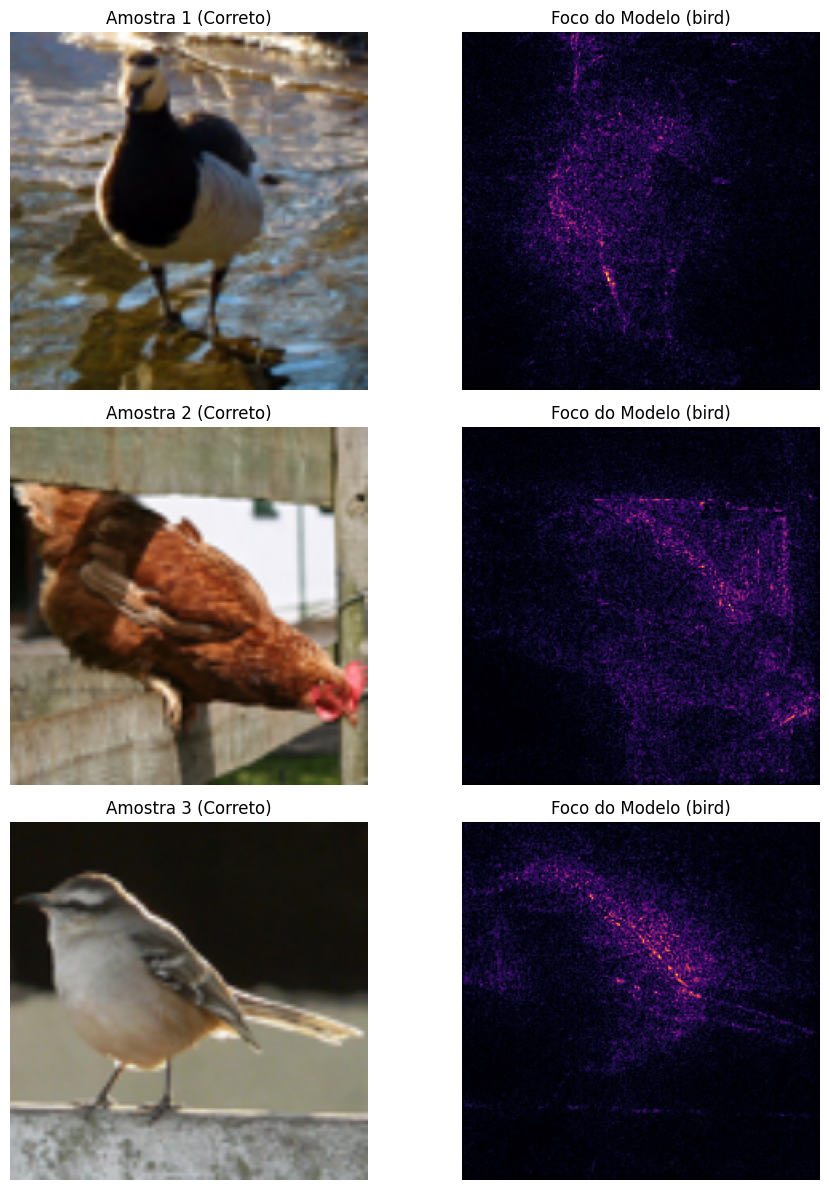

In [42]:
analyze_class_explanation(
    model_loaded, 
    loader_pt_test, 
    target_class=studied_class, 
    correct=True,       
    num_samples=3, 
    stats=stats_stl10, 
    device=device
)

--- Buscando 3 exemplos ERRADOS da classe 'bird' ---
Calculando atribuições (SmoothGrad)...


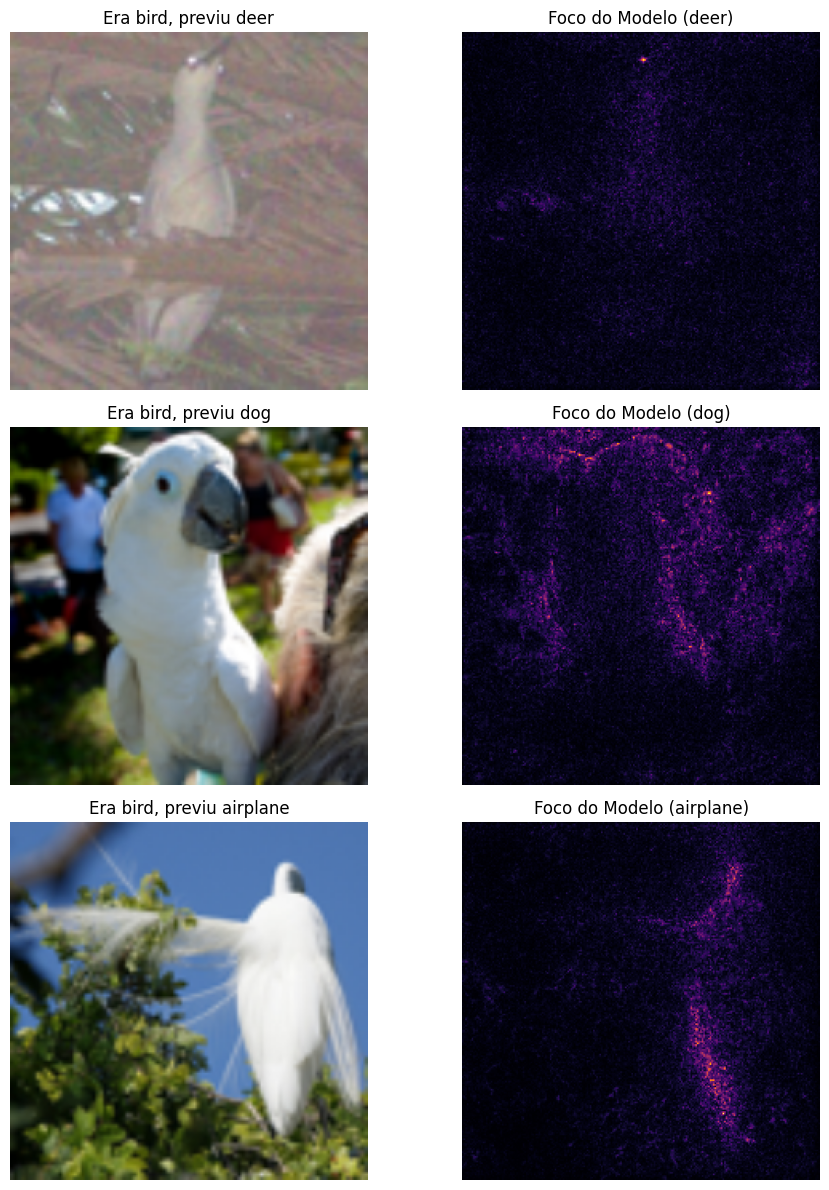

In [43]:
analyze_class_explanation(
    model_loaded, 
    loader_pt_test, 
    target_class=studied_class, 
    correct=False,       
    num_samples=3, 
    stats=stats_stl10, 
    device=device
)

## Shapley Value Sampling

--- Buscando 3 exemplos CORRETOS da classe 'bird' ---
Processando amostra 1/3...
Processando amostra 2/3...
Processando amostra 3/3...


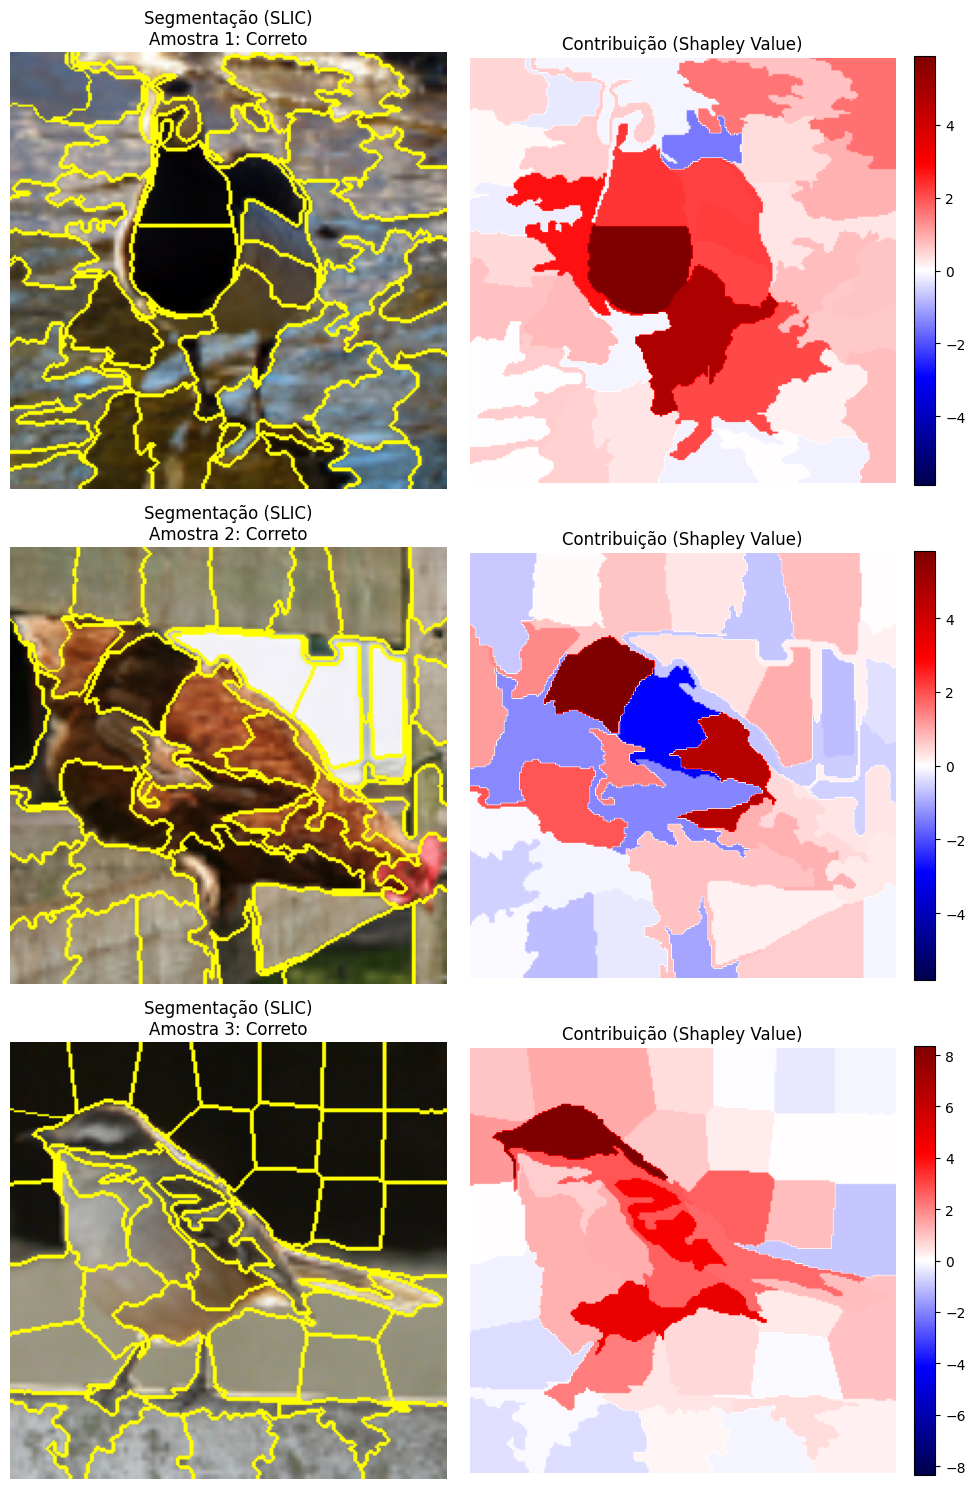

In [44]:
analyze_class_shapley(
    model_loaded, 
    loader_pt_test, 
    target_class=studied_class, 
    correct=True,
    num_samples=3,          # Quantas imagens
    stats=stats_stl10, 
    device=device,
    n_segments=50,          # Quantidade de 'peças' do quebra-cabeça
    n_samples_shapley=100    
)

--- Buscando 3 exemplos ERRADOS da classe 'bird' ---
Processando amostra 1/3...
Processando amostra 2/3...
Processando amostra 3/3...


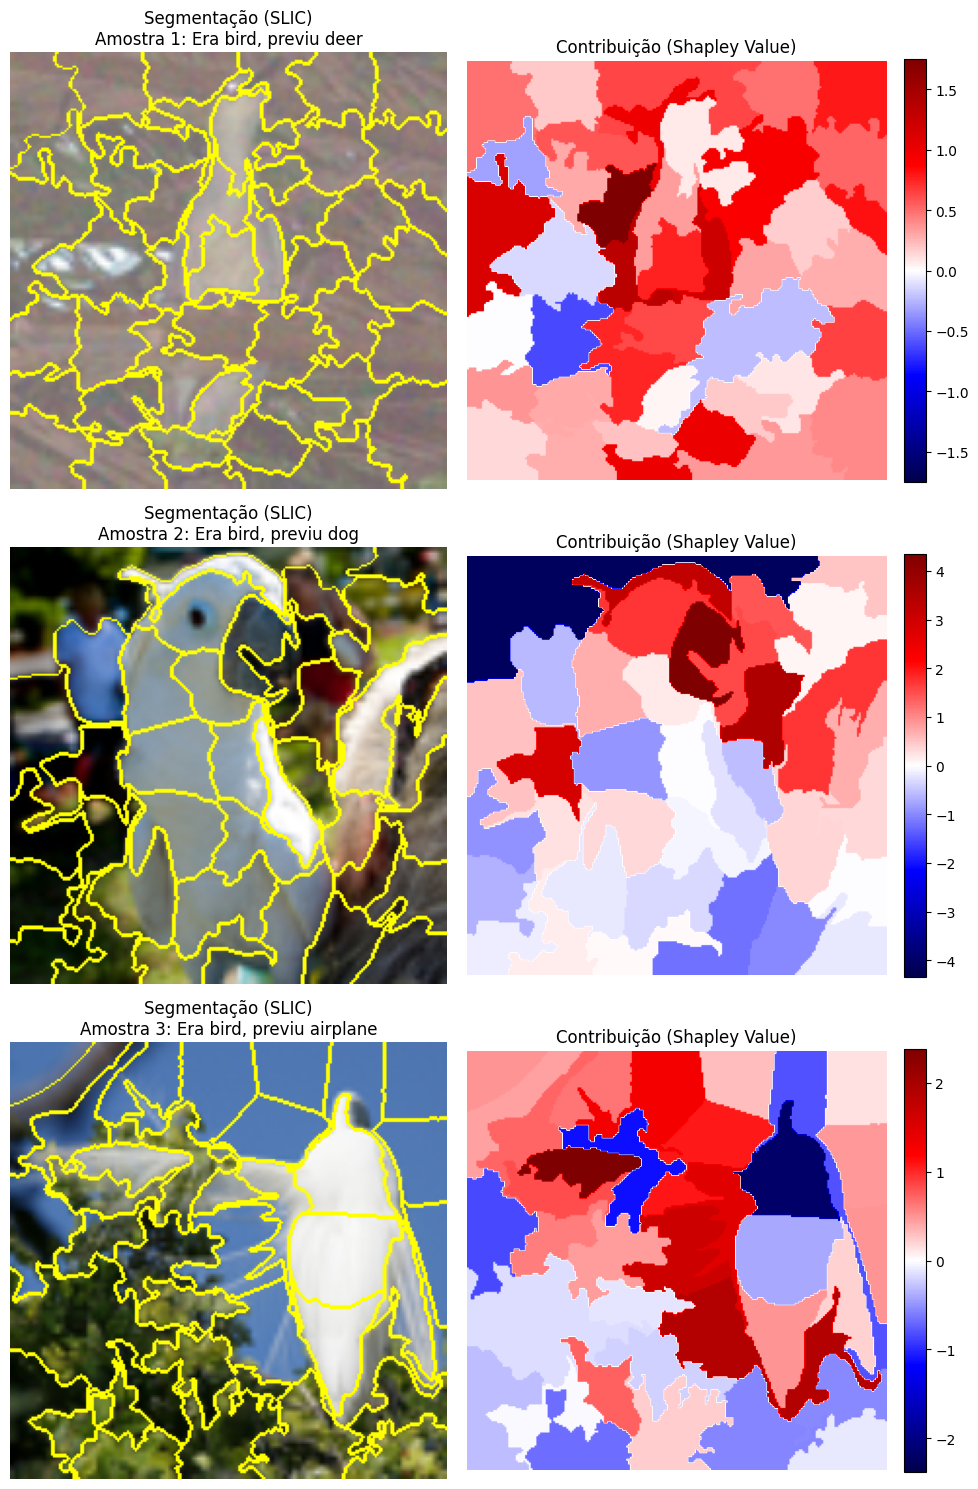

In [45]:
# Analisar 2 exemplos CORRETOS da classe "car"
analyze_class_shapley(
    model_loaded, 
    loader_pt_test, 
    target_class=studied_class, 
    correct=False,
    num_samples=3,          # Quantas imagens
    stats=stats_stl10, 
    device=device,
    n_segments=50,          # Quantidade de 'peças' do quebra-cabeça
    n_samples_shapley=100    
)